# Ejercicio 2

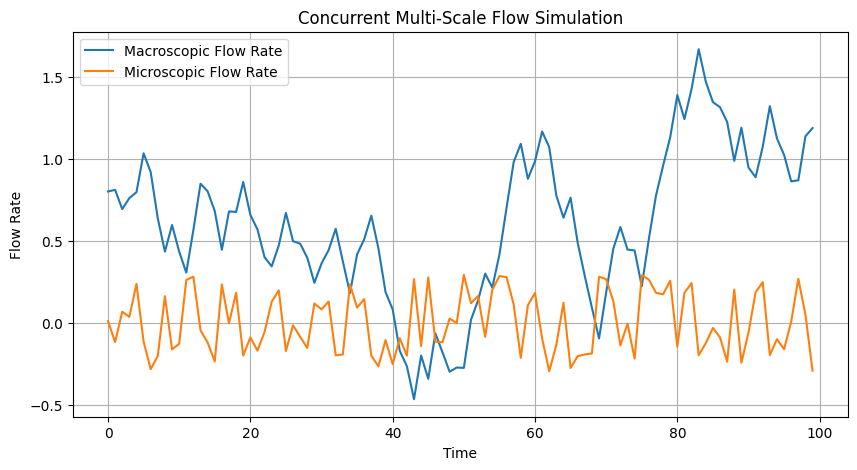

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_macroscopic_flow(permeability, pressure_gradient):
    flow_rate = permeability * pressure_gradient
    return flow_rate

def simulate_microscopic_flow(viscosity, velocity_gradient):
    flow_rate = -viscosity * velocity_gradient
    return flow_rate

def concurrent_multiscale_simulation(permeability, pressure_gradient, viscosity, time_steps):
    macroscopic_flow_rates = []
    microscopic_flow_rates = []
    
    for t in range(time_steps):
        macroscopic_flow = simulate_macroscopic_flow(permeability, pressure_gradient)
        macroscopic_flow_rates.append(macroscopic_flow)
        
        velocity_gradient = np.random.uniform(-0.1, 0.1) 
        microscopic_flow = simulate_microscopic_flow(viscosity, velocity_gradient)
        microscopic_flow_rates.append(microscopic_flow)
        
        pressure_gradient += microscopic_flow / permeability
        
    return macroscopic_flow_rates, microscopic_flow_rates

def visualize_flow_rates(macroscopic_flow_rates, microscopic_flow_rates):
    time_steps = len(macroscopic_flow_rates)
    time = np.arange(time_steps)
    
    plt.figure(figsize=(10, 5))
    plt.plot(time, macroscopic_flow_rates, label="Macroscopic Flow Rate")
    plt.plot(time, microscopic_flow_rates, label="Microscopic Flow Rate")
    plt.xlabel("Time")
    plt.ylabel("Flow Rate")
    plt.legend()
    plt.title("Concurrent Multi-Scale Flow Simulation")
    plt.grid()
    plt.show()

permeability = 1.0  
pressure_gradient = 0.8  
viscosity = 1.0  
time_steps = 100 

macroscopic_flow_rates, microscopic_flow_rates = concurrent_multiscale_simulation(
    permeability, pressure_gradient, viscosity, time_steps)


visualize_flow_rates(macroscopic_flow_rates, microscopic_flow_rates)


## Preguntas
### 1) ¿En qué se diferencia el enfoque multiescala concurrente del enfoque multiescala secuencial?
El enfoque multiescala concurrente lo que esta haciendo es que esta resolviendo lo macroescala y lo microescala al mismo tiempo, pasandose la información casi al mismo tiempo, como si fuese en tiempo real. Por el otro lado, lo secuencial lo que esta haciendo es que primero resuelve lo macroescala y después pasa la información a lo microescala, y viceversa, resolviendo todo lo mejor posible. A diferencia de lo concurrente, esto lo que hace no es simulación del tiempo real, ya que suelve una después de la otra dependiendo de lo que necesita.

### 2) ¿Qué información del modelo macroscópico se pasa al modelo microscópico y cómo afecta a la simulación microscópica?
Lo macroscopica la pasa información sobre su gradiente de presión, y afecta a lo macroscopico con su gradiente de velocidad que se utiliza en Navier-Scopes y el flujo a escala pequeña. Inversamente, cuando se tiene le gradiente de velocidad, este cambia el gradiente de presión, y lo devuelve al principio. Y finalmente, sigue el loop donde se manda la información de un ciclo a otro.##

### 3) ¿Cuáles son las ventajas de utilizar modelado multiescala concurrente en este escenario?
- Se tiene la simulación en tiempo real, ya que simua que todo esta pasando al mismo tiempo, y no se están tomando orden para las cosas.
- De la misma manera, como esta sucediendo en tiempo real, se tienen resultados más ciertos y verídicos a diferencia que si solo sea por aparte.
- Es mejor para la complejidad, ya que puede manejar las situaciones muy complicadas que se necesiten estar al mismo tiempo, y no necesatimete puedan ser separadas.
- Bueno para después mejorar y agregar cosas para saber que tan complejo en realidad puede ser.